In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/Dataset .csv")

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [3]:
print(df[["Restaurant Name", "Votes", "Aggregate rating"]].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Restaurant Name   9551 non-null   object 
 1   Votes             9551 non-null   int64  
 2   Aggregate rating  9551 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 224.0+ KB
None


In [4]:
highest_votes = (
    df[
        ["Restaurant Name", "City", "Votes", "Aggregate rating"]
    ]
    .sort_values(by="Votes", ascending=False)
    .head(10)
)

highest_votes

,Restaurant Name,City,Votes,Aggregate rating
728,Toit,Bangalore,10934,4.8
735,Truffles,Bangalore,9667,4.7
3994,Hauz Khas Social,New Delhi,7931,4.3
2412,Peter Cat,Kolkata,7574,4.3
739,AB's - Absolute Barbecues,Bangalore,6907,4.6
2414,Barbeque Nation,Kolkata,5966,4.9
743,Big Brewsky,Bangalore,5705,4.5
2307,AB's - Absolute Barbecues,Hyderabad,5434,4.9
736,The Black Pearl,Bangalore,5385,4.1
2411,BarBQ,Kolkata,5288,4.2


In [5]:
lowest_votes = (
    df[
        ["Restaurant Name", "City", "Votes", "Aggregate rating"]
    ]
    .sort_values(by="Votes", ascending=True)
    .head(10)
)

lowest_votes

,Restaurant Name,City,Votes,Aggregate rating
1173,Aha Bites,Gurgaon,0,0.0
1172,Achoos Food Corner,Gurgaon,0,0.0
8558,Food Town,Noida,0,0.0
6165,Zaika Restaurant,New Delhi,0,0.0
6164,Smily Cakes,New Delhi,0,0.0
6161,Roll Junction,New Delhi,0,0.0
1178,Gopi Sweets & Caters,Gurgaon,0,0.0
1186,Tanishk Gourmet Indian,Gurgaon,0,0.0
1185,Solty Hotel,Gurgaon,0,0.0
1183,OMG Tiffinz,Gurgaon,0,0.0


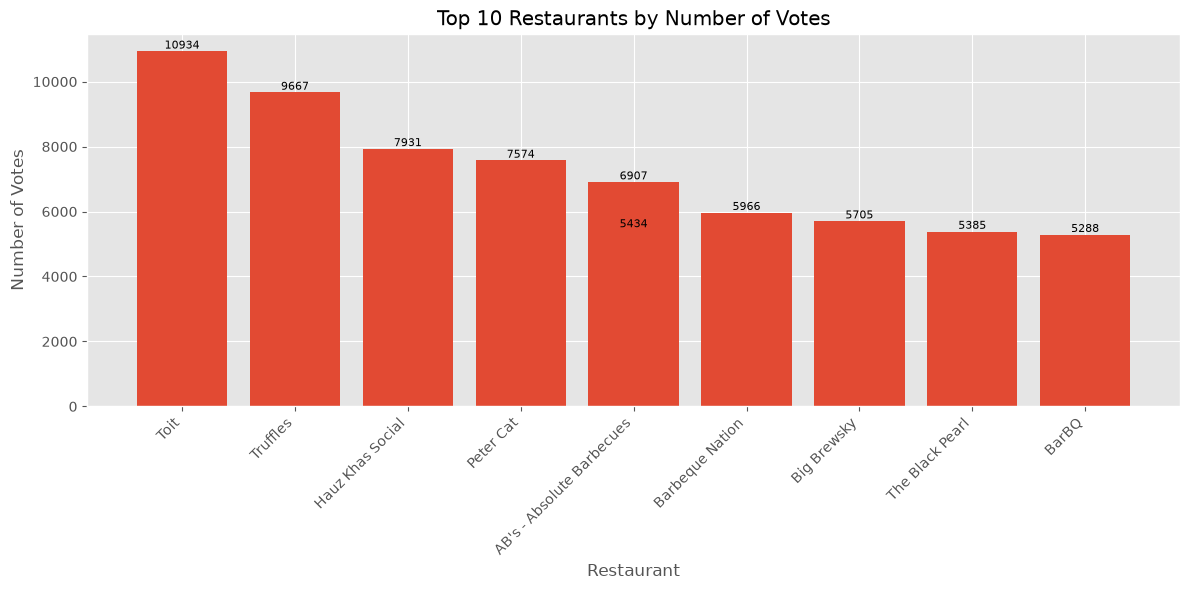

In [6]:
plt.figure(figsize=(12, 6))

bars = plt.bar(
    highest_votes["Restaurant Name"],
    highest_votes["Votes"]
)

plt.title("Top 10 Restaurants by Number of Votes")
plt.xlabel("Restaurant")
plt.ylabel("Number of Votes")

plt.xticks(rotation=45, ha="right")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        int(bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [7]:
correlation = df["Votes"].corr(df["Aggregate rating"])

print(f"Correlation between Votes and Rating: {correlation:.4f}")

Correlation between Votes and Rating: 0.3137


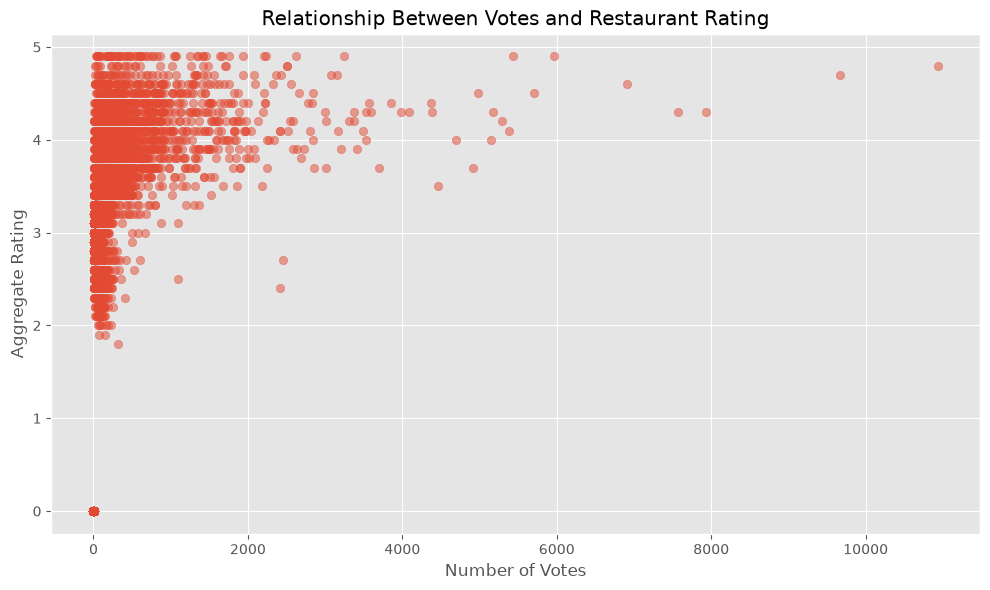

In [8]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Votes"],
    df["Aggregate rating"],
    alpha=0.5
)

plt.title("Relationship Between Votes and Restaurant Rating")
plt.xlabel("Number of Votes")
plt.ylabel("Aggregate Rating")

plt.tight_layout()
plt.show()

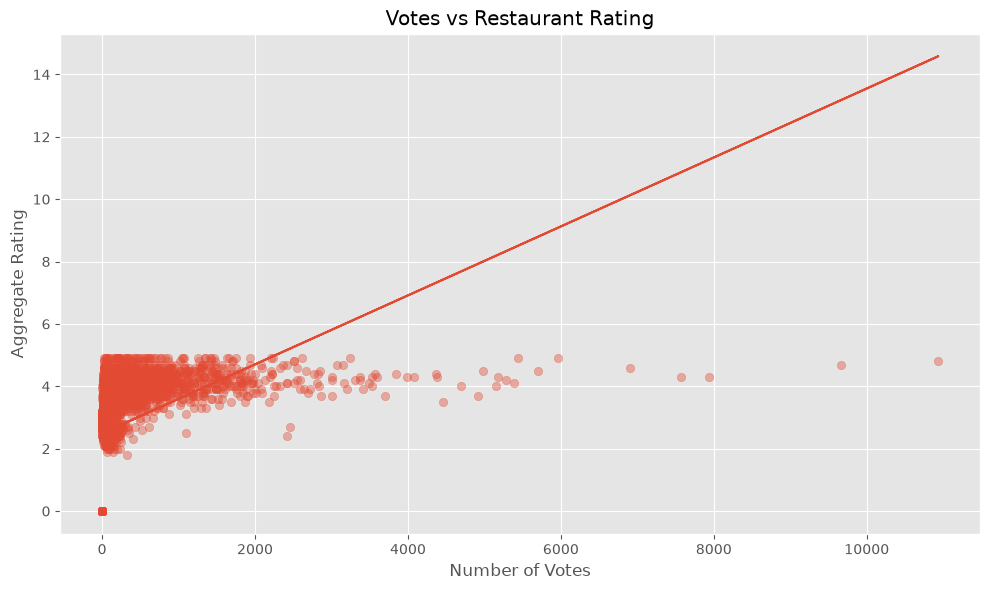

In [9]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Votes"],
    df["Aggregate rating"],
    alpha=0.4
)

z = __import__("numpy").polyfit(
    df["Votes"],
    df["Aggregate rating"],
    1
)

p = __import__("numpy").poly1d(z)

plt.plot(
    df["Votes"],
    p(df["Votes"])
)

plt.title("Votes vs Restaurant Rating")
plt.xlabel("Number of Votes")
plt.ylabel("Aggregate Rating")

plt.tight_layout()
plt.show()

In [10]:
if correlation > 0.7:
    interpretation = "Strong positive correlation"
elif correlation > 0.3:
    interpretation = "Moderate positive correlation"
elif correlation > 0:
    interpretation = "Weak positive correlation"
elif correlation < -0.7:
    interpretation = "Strong negative correlation"
elif correlation < -0.3:
    interpretation = "Moderate negative correlation"
else:
    interpretation = "Weak or negligible correlation"

print("Interpretation:", interpretation)

Interpretation: Moderate positive correlation


In [11]:
votes_summary = df[["Votes", "Aggregate rating"]].describe()

votes_summary

,Votes,Aggregate rating
count,9551.000000,9551.000000
mean,156.909748,2.666370
std,430.169145,1.516378
min,0.000000,0.000000
25%,5.000000,2.500000
50%,31.000000,3.200000
75%,131.000000,3.700000
max,10934.000000,4.900000


# Observations

- Identified the restaurants receiving the highest and lowest numbers of votes.
- Compared restaurant popularity using the number of votes received.
- Calculated the correlation between the number of votes and aggregate rating.
- Used a scatter plot to visualize the relationship between votes and ratings.
- The correlation coefficient indicates the strength and direction of the relationship between customer engagement and restaurant rating.
- A correlation value close to zero indicates little linear relationship, while a positive value indicates that higher-rated restaurants tend to receive more votes.